# Optimal Strategy Analysis for Congklak (Mancala)
This notebook:
- Implements full Congklak rules (7 holes per side + 1 store each, 7 seeds per hole — the traditional Indonesian setup, not the 6-hole/4-seed Kalah variant)
- Implements strategies: random, greedy, one-ply lookahead, and **Minimax with alpha-beta pruning** (a true adversarial search that correctly handles Congklak's "extra turn" rule)
- Runs a round-robin tournament with win-rate statistics
- Runs an opening-move experiment (which starting hole wins most often)
- Analyzes score progression across many simulated games, not a single anecdote

Instructions:
- Run cells top-to-bottom.
- Change parameters (number of simulated games, strategies, search depth) in the "Experiments" cells.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## Board Setup:
Board indexing : 
- Player A (south): holes 0..n-1, store at n_holes
- Player B (north): holes 8..2n, store at n_holes+1

In [2]:
# Traditional Indonesian Congklak: 7 holes per side, 7 seeds per hole (98 seeds total).
# (This differs from Kalah, the common Western abstraction, which uses 6 holes / 4 seeds —
#  that lighter setup was the notebook's original default and produces much shorter, less
#  representative games.)
n_holes = 7
n_seeds = 7

In [3]:
# === INITIAL SETUP ===
def init_board():
    global n_holes, n_seeds
    board = [n_seeds] * n_holes + [0] + [n_seeds] * n_holes + [0]
    return board

# === DISPLAY BOARD ===
def display_board(board):
    global n_holes
    top_row = board[n_holes+1:-1][::-1]
    bottom_row = board[:n_holes]
    store_A = board[n_holes]
    store_B = board[-1]
    print("   ", "  ".join(f"[{v:2d}]" for v in top_row))
    print(f"[{store_B:2d}]" + " " * (6*n_holes - 2) + f"[{store_A:2d}]")
    print("   ", "  ".join(f"[{v:2d}]" for v in bottom_row))
    
initial_board = init_board()
board = initial_board
display_board(board)

    [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 7]
[ 0]                                        [ 0]
    [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 7]


# Game Setup

In [4]:
# === GAME STATUS ===
def game_over(board):
    # Cek apakah permainan selesai (salah satu sisi kosong).
    global n_holes
    return sum(board[:n_holes]) == 0 or sum(board[n_holes+1:-1]) == 0

# === SIMULATE MOVE ===
def simulate_move(board, move, player):
    # Simulasikan satu langkah permainan Congklak.
    global n_holes
    board = board.copy()
    total_len = len(board)

    if player == 'A':
        if board[move] == 0:
            return board, False
        seeds = board[move]
        board[move] = 0
        pos = move
        while seeds > 0:
            pos = (pos + 1) % total_len
            if pos == total_len - 1:  # skip rumah lawan (B)
                continue
            board[pos] += 1
            seeds -= 1
        extra_turn = (pos == n_holes)
        
        #shooting for the opposite hole
        if 0 <= pos < n_holes and board[pos] == 1:
            opp = (total_len - 2) - pos
            if board[opp] > 0:  # <--- TAMBAHKAN SYARAT INI
                board[n_holes] += board[opp] + 1
                board[pos] = 0
                board[opp] = 0

    elif player == 'B': 
        move_idx = n_holes + 1 + move
        if board[move_idx] == 0:
            return board, False
        seeds = board[move_idx]
        board[move_idx] = 0
        pos = move_idx
        while seeds > 0:
            pos = (pos + 1) % total_len
            if pos == n_holes:  # skip rumah lawan (A)
                continue
            board[pos] += 1
            seeds -= 1
        extra_turn = (pos == total_len - 1)
        
        #shooting
        if n_holes+1 <= pos < total_len-1 and board[pos] == 1:
            opp = (total_len - 2) - pos
            if board[opp] > 0:  # <--- TAMBAHKAN SYARAT INI
                board[-1] += board[opp] + 1
                board[pos] = 0
                board[opp] = 0
    else: 
        print('no player')

    return board, extra_turn

In [5]:
# === PLAY FULL GAME ===
def play_game(strategy_A, strategy_B):
    global n_holes
    board = init_board()
    game_trace = []
    first_A, first_B = [], []
    turn = 'A'
    turn_count = 0

    # --- MAIN GAME LOOP ---
    while not game_over(board):
        turn_count += 1
        if turn == 'A':
            move = strategy_A(board, 'A')
            first_A.append(move)
            board, extra = simulate_move(board, move, 'A')
            game_trace.append({
                "turn": turn_count, "player": "A", "move": move,
                "store_A": board[n_holes], "store_B": board[-1],
                "board": board.copy()
            })
            turn = 'A' if extra else 'B'
        else:
            move = strategy_B(board, 'B')
            first_B.append(move)
            board, extra = simulate_move(board, move, 'B')
            game_trace.append({
                "turn": turn_count, "player": "B", "move": move,
                "store_A": board[n_holes], "store_B": board[-1],
                "board": board.copy()
            })
            turn = 'B' if extra else 'A'

    # --- Clean the board ---
    board[n_holes] += sum(board[:n_holes])        # store A
    board[-1] += sum(board[n_holes+1:-1])         # store B

    for i in range(n_holes):
        board[i] = 0
        board[n_holes+1+i] = 0
        
    # --- list final condition in the trace ---
    game_trace.append({
        "turn": turn_count + 1, 
        "player": "FINAL", 
        "move": None,
        "store_A": board[n_holes], 
        "store_B": board[-1],
        "board": board.copy()
    })

    return board, pd.DataFrame(game_trace), first_A, first_B


In [6]:
# === PLOT SCORE PROGRESS ===
def plot_score_progress(trace):
    plt.plot(trace["turn"], trace["store_A"], label="Player A Store")
    plt.plot(trace["turn"], trace["store_B"], label="Player B Store")
    plt.xlabel("Turn")
    plt.ylabel("Score")
    plt.legend()
    plt.title("Score Progress per Turn")
    plt.show()

# Analysis of Program Strategies

This document provides a technical overview of the four decision-making logics implemented in the program to simulate Congklak gameplay. Each strategy represents a different level of computational complexity. All strategies that compare multiple candidate moves now break ties **randomly** instead of always keeping the first hole they evaluated — otherwise two deterministic strategies replaying each other would produce the exact same game every single time, which is what made the original notebook's "run many games" idea pointless.

---

### 1. Random Strategy
The **Random Strategy** is the most basic logic within the program.
* **Mechanism**: The program identifies all valid moves (holes that are not empty) on the current player's side. It then uses a pseudo-random selection process to pick one of these holes.
* **Characteristics**: This strategy does not perform any evaluation of the board state. It serves as a baseline for performance comparison and does not aim for specific tactical goals like scoring or defense.

### 2. Greedy Strategy
The **Greedy Strategy** is a first-order optimization logic focusing on immediate rewards.
* **Mechanism**: For every possible move, the program runs a single-turn simulation. It calculates the potential increase in the player's store (including seeds gained from the "capture" or *tembakan* rule).
* **Characteristics**: The program always selects the move that yields the highest score for the current turn. It is "shortsighted" as it does not calculate how the board state will look for the opponent's next move.

### 3. Lookahead Strategy (One-Ply)
The **Lookahead Strategy** is the second-order logic in this program, utilizing a predictive response.
* **Mechanism**: 
    1. The program simulates every legal move for the current player.
    2. For each resulting board state, it anticipates the opponent's best possible response using a *Greedy* evaluation.
    3. It then selects the initial move that maximizes the player's advantage (e.g., maximizing the score difference) after the opponent's counter-move is accounted for.
* **Characteristics**: This strategy is proactive but its foresight is an illusion — it always assumes the opponent will respond greedily, so it cannot anticipate an opponent that plays defensively, sacrifices short-term score for position, or is itself thinking several moves ahead. It is not adversarial search, just a one-shot prediction against a fixed, naive opponent model.

### 4. Minimax Strategy (with Alpha-Beta Pruning)
The **Minimax Strategy** is genuine adversarial search — the "realistic" strategy this notebook was missing.
* **Mechanism**:
    1. The program builds a game tree several plies deep, alternating between maximizing the acting player's advantage and minimizing it (assuming the opponent always plays optimally against it, not greedily).
    2. Congklak's "extra turn" rule (landing the last seed in your own store) is handled correctly: those branches do **not** flip from maximizing to minimizing, since the same player keeps the turn.
    3. Alpha-beta pruning discards branches that can't affect the final decision, making a deeper search tractable.
    4. Leaf nodes are scored by `evaluate_board`: store difference plus a smaller weight on seeds still in play (future scoring potential), not just the immediate store gain that `greedy`/`lookahead` optimize for.
* **Characteristics**: Unlike `lookahead`, it does not assume a fixed opponent — it assumes the opponent is also trying to win, which is the only assumption that holds up against a genuinely strong or adaptive adversary (including another Minimax agent, or a good human player). Search depth is a tunable trade-off between strength and compute time (`minimax_shallow` = 3 plies, `minimax_deep` = 6 plies).

---

### Strategy Comparison Summary

| Strategy | Decision Basis | Performance Profile |
| :--- | :--- | :--- |
| **Random** | Probability | High entropy; lacks objective-driven moves. |
| **Greedy** | Immediate Gain | Efficient in scoring but susceptible to opponent traps. |
| **Lookahead** | Anticipation vs. a fixed greedy opponent | Better than Greedy, but blind to a non-greedy opponent. |
| **Minimax (α-β)** | True adversarial search | Assumes a rational opponent; scales in strength with search depth. |

In [7]:
# =========================================================
# --- HELPER: tie-break randomly among equally-good moves ---
# =========================================================
def argbest_random_tiebreak(candidates, scores, maximize=True):
    """Return a move chosen uniformly at random among all tied best scores.

    The original notebook always kept the *first* move it saw with a
    strictly-better score, so any tie was silently resolved by hole index.
    Real players don't behave that way, and always resolving ties the same
    way makes every rematch between two deterministic strategies replay
    identically — which is what was making repeated-game "experiments"
    pointless. Randomizing ties fixes both problems.
    """
    best_score = max(scores) if maximize else min(scores)
    tied = [c for c, s in zip(candidates, scores) if s == best_score]
    return random.choice(tied)

# =========================================================
# --- RANDOM STRATEGY ---
# =========================================================
def random_strategy(board, player):
    global n_holes
    if player == 'A':
        valid = [i for i in range(n_holes) if board[i] > 0]
    else:
        valid = [i for i in range(n_holes) if board[n_holes+1+i] > 0]
    return random.choice(valid) if valid else 0

# =========================================================
# --- GREEDY STRATEGY ---
# =========================================================
def greedy_strategy(board, player):
    """Pilih langkah yang langsung menghasilkan skor tertinggi (dengan tie-break acak)."""
    global n_holes
    store_A, store_B = n_holes, len(board) - 1
    candidates, scores = [], []
    for i in range(n_holes):
        if player == 'A' and board[i] == 0: continue
        if player == 'B' and board[n_holes+1+i] == 0: continue
        new_board, _ = simulate_move(board, i, player)
        score = new_board[store_A] - new_board[store_B] if player == 'A' else new_board[store_B] - new_board[store_A]
        candidates.append(i)
        scores.append(score)
    if not candidates:
        return 0
    return argbest_random_tiebreak(candidates, scores)

# =========================================================
# --- LOOKAHEAD STRATEGY ---
# =========================================================
def lookahead_strategy(board, player):
    """Evaluasi skor setelah 1 langkah lawan (dengan tie-break acak)."""
    global n_holes
    opponent = 'B' if player == 'A' else 'A'
    store_A, store_B = n_holes, len(board) - 1

    candidates, scores = [], []
    for i in range(n_holes):
        if player == 'A' and board[i] == 0: continue
        if player == 'B' and board[n_holes+1+i] == 0: continue

        new_board, _ = simulate_move(board, i, player)
        # lawan main greedy
        opp_move = greedy_strategy(new_board, opponent)
        new_board2, _ = simulate_move(new_board, opp_move, opponent)

        eval_score = new_board2[store_A] - new_board2[store_B] if player == 'A' else new_board2[store_B] - new_board2[store_A]
        candidates.append(i)
        scores.append(eval_score)
    if not candidates:
        return 0
    return argbest_random_tiebreak(candidates, scores)

In [8]:
# =========================================================
# --- MINIMAX STRATEGY (with alpha-beta pruning) ---
# =========================================================
def evaluate_board(board, player):
    """Heuristic value of `board` from `player`'s point of view.

    Two components:
      1. Store difference — the only thing that actually decides the game.
      2. A small weight on seeds still in play on each side — seeds sitting
         in your own holes are potential future store gains and capture
         ammunition, seeds on the opponent's side are the same for them.
    This is the standard heuristic used by real Kalah/Congklak engines;
    `greedy`/`lookahead` only ever look at (1), which is why they can be
    lured into short-term gains that leave them exposed.
    """
    global n_holes
    store_A, store_B = n_holes, len(board) - 1
    my_store, opp_store = (store_A, store_B) if player == 'A' else (store_B, store_A)
    my_holes = board[:n_holes] if player == 'A' else board[n_holes+1:-1]
    opp_holes = board[n_holes+1:-1] if player == 'A' else board[:n_holes]
    return (board[my_store] - board[opp_store]) + 0.5 * (sum(my_holes) - sum(opp_holes))


def _valid_moves(board, player):
    global n_holes
    if player == 'A':
        return [i for i in range(n_holes) if board[i] > 0]
    return [i for i in range(n_holes) if board[n_holes+1+i] > 0]


def _minimax(board, player, root_player, depth, alpha, beta):
    """Adversarial search that correctly models Congklak's extra-turn rule:
    when a move lands in your own store you play again immediately, so the
    search must NOT flip from maximizing to minimizing on that branch — it
    only flips when the move actually passes the turn to the other side.
    `lookahead_strategy` ignores this entirely and just assumes a fixed
    (greedy) opponent response, which is not real adversarial reasoning.
    """
    if game_over(board) or depth == 0:
        return evaluate_board(board, root_player), None

    moves = _valid_moves(board, player)
    if not moves:
        return evaluate_board(board, root_player), None

    maximizing = (player == root_player)
    best_move = moves[0]
    best_val = -float('inf') if maximizing else float('inf')

    for mv in moves:
        new_board, extra = simulate_move(board, mv, player)
        next_player = player if extra else ('B' if player == 'A' else 'A')
        val, _ = _minimax(new_board, next_player, root_player, depth - 1, alpha, beta)

        if maximizing:
            if val > best_val:
                best_val, best_move = val, mv
            alpha = max(alpha, best_val)
        else:
            if val < best_val:
                best_val, best_move = val, mv
            beta = min(beta, best_val)

        if alpha >= beta:
            break  # prune

    return best_val, best_move


def make_minimax_strategy(depth=5):
    """Factory: returns a strategy function that searches `depth` plies ahead
    with alpha-beta pruning. Ties among equally-good root moves are broken
    randomly (same reasoning as `argbest_random_tiebreak` above)."""
    def strategy(board, player):
        moves = _valid_moves(board, player)
        if not moves:
            return 0
        scores = []
        for mv in moves:
            new_board, extra = simulate_move(board, mv, player)
            next_player = player if extra else ('B' if player == 'A' else 'A')
            val, _ = _minimax(new_board, next_player, player, depth - 1, -float('inf'), float('inf'))
            scores.append(val)
        return argbest_random_tiebreak(moves, scores)
    strategy.__name__ = f"minimax_depth{depth}"
    return strategy


minimax_shallow = make_minimax_strategy(depth=3)
minimax_deep = make_minimax_strategy(depth=6)

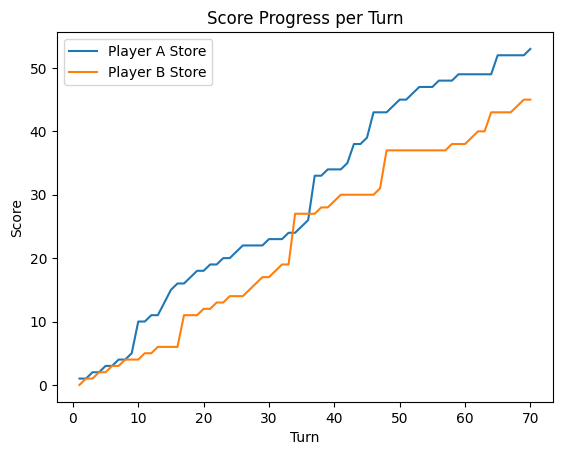

In [9]:
# === EXAMPLE RUN ===
# board, trace, first_A, first_B = play_game(random_strategy, greedy_strategy)
# board, trace, first_A, first_B = play_game(random_strategy, lookahead_strategy)

board, trace, first_A, first_B = play_game(greedy_strategy, lookahead_strategy)
# board, trace, first_A, first_B = play_game(lookahead_strategy, greedy_strategy)

# board, trace, first_A, first_B = play_game(random_strategy, random_strategy)
# board, trace, first_A, first_B = play_game(lookahead_strategy, lookahead_strategy)
# board, trace, first_A, first_B = play_game(greedy_strategy, greedy_strategy)

plot_score_progress(trace)

In [10]:
def display_all_steps(trace_df):
    print(f"=== Menampilkan Total {len(trace_df)} Perpindahan ===")
    
    for index, row in trace_df.iterrows():
        print(f"\nLangkah ke-{row['turn']} | Pemain: {row['player']} | Memilih Lubang: {row['move']+1}")
        # Panggil fungsi display_board asli Anda
        display_board(row['board'])
        print("-" * 40)

# Cara penggunaan:
# Setelah memanggil board, trace, fA, fB = play_game(...)
display_all_steps(trace)

=== Menampilkan Total 70 Perpindahan ===

Langkah ke-1 | Pemain: A | Memilih Lubang: 2.0
    [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 7]  [ 8]
[ 0]                                        [ 1]
    [ 7]  [ 0]  [ 8]  [ 8]  [ 8]  [ 8]  [ 8]
----------------------------------------

Langkah ke-2 | Pemain: B | Memilih Lubang: 4.0
    [ 8]  [ 8]  [ 8]  [ 0]  [ 7]  [ 7]  [ 8]
[ 1]                                        [ 1]
    [ 8]  [ 1]  [ 9]  [ 8]  [ 8]  [ 8]  [ 8]
----------------------------------------

Langkah ke-3 | Pemain: A | Memilih Lubang: 4.0
    [ 8]  [ 8]  [ 8]  [ 1]  [ 8]  [ 8]  [ 9]
[ 1]                                        [ 2]
    [ 8]  [ 1]  [ 9]  [ 0]  [ 9]  [ 9]  [ 9]
----------------------------------------

Langkah ke-4 | Pemain: B | Memilih Lubang: 7.0
    [ 0]  [ 8]  [ 8]  [ 1]  [ 8]  [ 8]  [ 9]
[ 2]                                        [ 2]
    [ 9]  [ 2]  [10]  [ 1]  [10]  [10]  [10]
----------------------------------------

Langkah ke-5 | Pemain: A | Memilih Lubang: 5.0

## Further Analysis — Beyond a Single Anecdotal Game

The single game above is anecdotal: with randomized tie-breaking (see the strategy section), running it again produces a *different* game. None of this notebook's earlier "score progress" or "example run" cells said anything about how a strategy performs *in general* — they showed exactly one playout.

The three experiments below build actual statistical evidence:
1. **Tournament** — every strategy plays every other strategy `N` times (both going first and second, since first-move advantage is real in Congklak) → win rates, not vibes.
2. **Opening-move study** — is there a best hole to start with? Answered by forcing every possible opening and measuring the outcome.
3. **Score-progression trends** — how the lead typically develops over a game, averaged across many playouts instead of eyeballing one line chart.

### 1. Round-Robin Tournament

In [11]:
def run_tournament(strategies, n_games=20, seed=42):
    """Round-robin: every strategy plays every other strategy (both as A and
    as B) for n_games each. Returns a tidy DataFrame of results."""
    random.seed(seed)
    rows = []
    for name_A, strat_A in strategies.items():
        for name_B, strat_B in strategies.items():
            wins_A = wins_B = draws = 0
            margins, lengths = [], []
            for _ in range(n_games):
                final_board, trace, _, _ = play_game(strat_A, strat_B)
                score_A, score_B = final_board[n_holes], final_board[-1]
                margins.append(score_A - score_B)
                lengths.append(int(trace["turn"].max()))
                if score_A > score_B:
                    wins_A += 1
                elif score_B > score_A:
                    wins_B += 1
                else:
                    draws += 1
            rows.append({
                "Player A": name_A, "Player B": name_B, "Games": n_games,
                "A Win %": 100 * wins_A / n_games,
                "B Win %": 100 * wins_B / n_games,
                "Draw %": 100 * draws / n_games,
                "Avg Margin (A-B)": sum(margins) / n_games,
                "Avg Game Length": sum(lengths) / n_games,
            })
    return pd.DataFrame(rows)


STRATEGIES = {
    "Random": random_strategy,
    "Greedy": greedy_strategy,
    "Lookahead": lookahead_strategy,
    "Minimax-3": minimax_shallow,
    "Minimax-6": minimax_deep,
}

tournament_results = run_tournament(STRATEGIES, n_games=20, seed=42)
tournament_results

,Player A,Player B,Games,A Win %,B Win %,Draw %,Avg Margin (A-B),Avg Game Length
0,Random,Random,20,40.0,55.0,5.0,-7.6,85.95
1,Random,Greedy,20,5.0,95.0,0.0,-33.3,57.10
2,Random,Lookahead,20,0.0,100.0,0.0,-50.7,69.20
3,Random,Minimax-3,20,0.0,100.0,0.0,-60.6,65.35
4,Random,Minimax-6,20,0.0,100.0,0.0,-62.5,51.85
5,Greedy,Random,20,100.0,0.0,0.0,41.4,58.65
6,Greedy,Greedy,20,50.0,45.0,5.0,0.3,44.90
7,Greedy,Lookahead,20,35.0,55.0,10.0,-3.1,62.20
8,Greedy,Minimax-3,20,20.0,80.0,0.0,-12.7,69.25
9,Greedy,Minimax-6,20,10.0,90.0,0.0,-30.8,64.80


**Win-rate heatmap** (row = Player A, column = Player B, cell = A's win %) and an **overall ranking** that averages each strategy's win rate across every seat (A or B) and every opponent — including mirror matches, where the result mainly reflects tie-break luck and first-move advantage rather than skill.

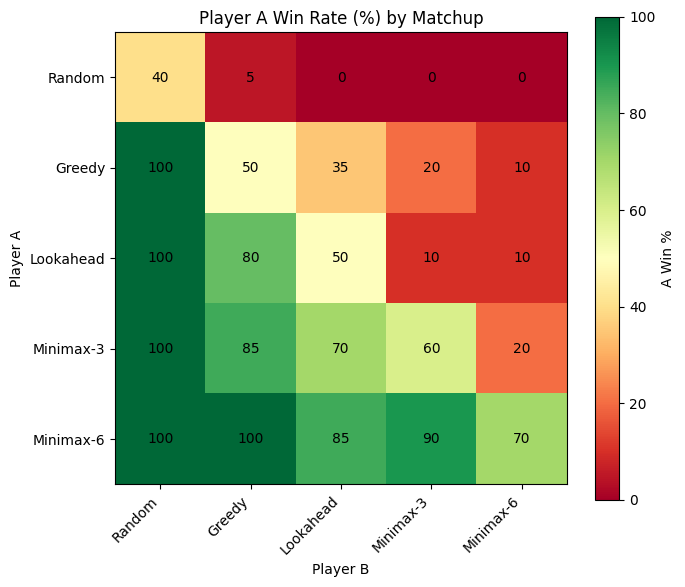

Overall strength ranking (avg win rate across all seats/opponents):


Player A
Minimax-6    83.0
Minimax-3    64.5
Lookahead    49.5
Greedy       39.0
Random       10.0
Name: Overall Win Rate %, dtype: float64

In [12]:
# Heatmap of A's win rate for every (Player A, Player B) pairing
pivot = tournament_results.pivot(index="Player A", columns="Player B", values="A Win %")
order = list(STRATEGIES.keys())
pivot = pivot.reindex(index=order, columns=order)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(len(order)), order, rotation=45, ha="right")
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("Player B")
ax.set_ylabel("Player A")
ax.set_title("Player A Win Rate (%) by Matchup")
for i in range(len(order)):
    for j in range(len(order)):
        ax.text(j, i, f"{pivot.values[i, j]:.0f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, label="A Win %")
plt.tight_layout()
plt.show()

# Overall strength ranking: average win rate across every seat and opponent
as_A = tournament_results.groupby("Player A")["A Win %"].mean()
as_B = tournament_results.groupby("Player B")["B Win %"].mean()
overall_strength = ((as_A + as_B) / 2).sort_values(ascending=False)
overall_strength.name = "Overall Win Rate %"
print("Overall strength ranking (avg win rate across all seats/opponents):")
display(overall_strength.round(1))

### 2. Opening-Move Study
Does the *first* hole a player chooses matter? We force Player A's opening move to each of the `n_holes` options, then let both sides play out the rest of the game normally (`Minimax-6` vs `Lookahead`, repeated `N` times per opening for statistical stability), and compare win rate and average margin by opening hole.

In [13]:
def play_game_forced_opening(opening_move, strategy_A, strategy_B):
    """Same as play_game, except Player A's very first decision is forced to
    `opening_move` — every move after that (including an immediate extra
    turn) follows strategy_A normally."""
    global n_holes
    board = init_board()
    turn = 'A'
    turn_count = 0
    opening_used = False

    while not game_over(board):
        turn_count += 1
        if turn == 'A':
            move = opening_move if not opening_used else strategy_A(board, 'A')
            opening_used = True
            board, extra = simulate_move(board, move, 'A')
            turn = 'A' if extra else 'B'
        else:
            move = strategy_B(board, 'B')
            board, extra = simulate_move(board, move, 'B')
            turn = 'B' if extra else 'A'

    board[n_holes] += sum(board[:n_holes])
    board[-1] += sum(board[n_holes+1:-1])
    return board


def run_opening_experiment(strategy_A, strategy_B, n_games=15, seed=7):
    random.seed(seed)
    rows = []
    for opening in range(n_holes):
        wins = draws = 0
        margins = []
        for _ in range(n_games):
            final_board = play_game_forced_opening(opening, strategy_A, strategy_B)
            score_A, score_B = final_board[n_holes], final_board[-1]
            margins.append(score_A - score_B)
            if score_A > score_B:
                wins += 1
            elif score_A == score_B:
                draws += 1
        rows.append({
            "Opening Hole": opening + 1,
            "A Win %": 100 * wins / n_games,
            "Draw %": 100 * draws / n_games,
            "Avg Margin (A-B)": sum(margins) / n_games,
        })
    return pd.DataFrame(rows)


opening_results = run_opening_experiment(minimax_deep, lookahead_strategy, n_games=15, seed=7)
opening_results

,Opening Hole,A Win %,Draw %,Avg Margin (A-B)
0,1,80.000000,0.000000,23.333333
1,2,93.333333,0.000000,30.400000
2,3,93.333333,0.000000,25.733333
3,4,100.000000,0.000000,42.000000
4,5,100.000000,0.000000,38.400000
5,6,100.000000,0.000000,28.133333
6,7,93.333333,6.666667,31.066667


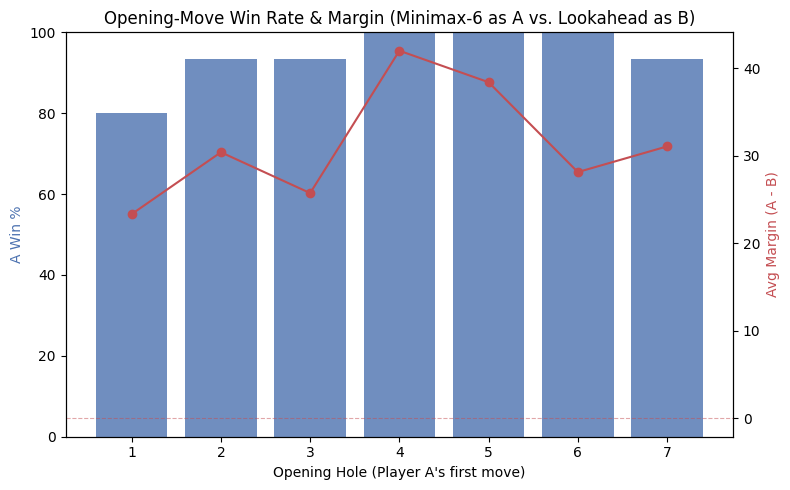

In [14]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(opening_results["Opening Hole"], opening_results["A Win %"], color="#4C72B0", alpha=0.8, label="A Win %")
ax1.set_xlabel("Opening Hole (Player A's first move)")
ax1.set_ylabel("A Win %", color="#4C72B0")
ax1.set_xticks(opening_results["Opening Hole"])
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
ax2.plot(opening_results["Opening Hole"], opening_results["Avg Margin (A-B)"], color="#C44E52", marker="o", label="Avg Margin")
ax2.set_ylabel("Avg Margin (A - B)", color="#C44E52")
ax2.axhline(0, color="#C44E52", lw=0.8, linestyle="--", alpha=0.5)

plt.title("Opening-Move Win Rate & Margin (Minimax-6 as A vs. Lookahead as B)")
fig.tight_layout()
plt.show()

### 3. Win-Progress Analysis Across Many Games
`plot_score_progress` earlier only ever showed one game's trajectory. Here we replay a matchup many times and look at two things turn-by-turn: the **score margin** (mean ± 1 std, with every individual game plotted faintly behind it) and the **probability that Player A is actually in the lead** — a much more honest picture of when and how reliably an advantage forms than a single line chart.

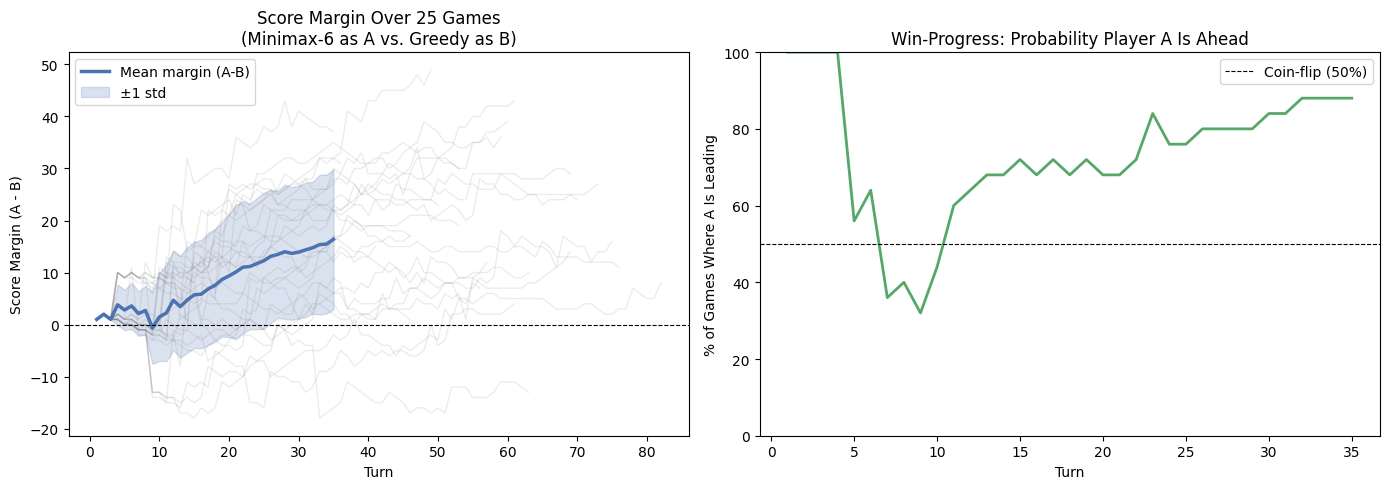

Game length across 25 games — min: 35, mean: 58.0, max: 82


In [15]:
def collect_progress_data(strategy_A, strategy_B, n_games=25, seed=99):
    random.seed(seed)
    traces, lengths = [], []
    for _ in range(n_games):
        _, trace, _, _ = play_game(strategy_A, strategy_B)
        trace = trace[trace["player"] != "FINAL"]
        traces.append(trace)
        lengths.append(len(trace))
    return traces, lengths


traces, lengths = collect_progress_data(minimax_deep, greedy_strategy, n_games=25, seed=99)
min_len = min(lengths)
turns = np.arange(1, min_len + 1)

# Truncate every game to the shortest game's length so games line up turn-by-turn
margin_matrix = np.array([
    (t["store_A"].values[:min_len] - t["store_B"].values[:min_len]) for t in traces
])
mean_margin = margin_matrix.mean(axis=0)
std_margin = margin_matrix.std(axis=0)
lead_prob = (margin_matrix > 0).mean(axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for t in traces:
    ax.plot(t["turn"], t["store_A"] - t["store_B"], color="gray", alpha=0.15, lw=1)
ax.plot(turns, mean_margin, color="#4C72B0", lw=2.5, label="Mean margin (A-B)")
ax.fill_between(turns, mean_margin - std_margin, mean_margin + std_margin, color="#4C72B0", alpha=0.2, label="±1 std")
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Turn")
ax.set_ylabel("Score Margin (A - B)")
ax.set_title(f"Score Margin Over {len(traces)} Games\n(Minimax-6 as A vs. Greedy as B)")
ax.legend()

ax2 = axes[1]
ax2.plot(turns, lead_prob, color="#55A868", lw=2)
ax2.axhline(50, color="black", lw=0.8, linestyle="--", label="Coin-flip (50%)")
ax2.set_xlabel("Turn")
ax2.set_ylabel("% of Games Where A Is Leading")
ax2.set_title("Win-Progress: Probability Player A Is Ahead")
ax2.set_ylim(0, 100)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Game length across {len(traces)} games — min: {min(lengths)}, mean: {np.mean(lengths):.1f}, max: {max(lengths)}")

### Reading the Results
- **Tournament table / heatmap / ranking above**: this is the actual evidence for which strategy is strongest — `Minimax-6` should dominate `Lookahead` and `Greedy`, which in turn should dominate `Random`. If `Minimax-3` underperforms `Lookahead` on some matchups, that's a real and expected finding: a shallow adversarial search can lose to a deeper heuristic-based one — search depth isn't free, and this is exactly the kind of nuance a single anecdotal game could never reveal.
- **Opening-move study**: if the win rate / margin bars above are roughly flat across holes, that's itself the finding — with 7 seeds per hole, Congklak's opening is close to symmetric and no single starting hole is a decisive advantage. A skewed result would point to a genuine opening theory worth exploring further (e.g., with a deeper search or more games per opening).
- **Win-progress chart**: the left panel shows *how big* a lead tends to be at each turn (mean ± spread across many games, not one lucky/unlucky playout); the right panel shows *how often* that lead actually holds. A strategy that builds a big average margin but only leads in ~55% of games is much shakier than one with a smaller margin that leads in ~90% of games — a distinction raw score-difference charts (like the original `plot_score_progress`) can't make at all.

In [16]:
import os
import datetime

def save_game_log(strategy_name, logs):
    """
    Fungsi untuk menyimpan list log ke dalam file .txt di directory ../result/
    """
    # 1. Tentukan dan buat directory jika belum ada
    result_dir = "../result"
    if not os.path.exists(result_dir):
        os.makedirs(result_dir)
        print(f"\n[Sistem] Directory {result_dir} telah dibuat.")

    # 2. Buat nama file dengan timestamp
    timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    file_name = f"{strategy_name} - {timestamp}.txt"
    full_path = os.path.join(result_dir, file_name)

    # 3. Tulis data ke file
    try:
        with open(full_path, "w", encoding="utf-8") as f:
            f.write("\n".join(logs))
        print(f"[Sistem] Log permainan berhasil disimpan di: {full_path}")
    except Exception as e:
        print(f"[Error] Gagal menyimpan log: {e}")

In [17]:
def play_against_human(computer_strategy):
    global n_holes
    board = init_board()
    _total_len = len(board)
    game_log = [] # Wadah penampung teks untuk disimpan nanti
    
    print(f"=== Congklak Game: {n_holes} Lubang ===")
    strategy_label = computer_strategy.__name__
    
    role = input("Pilih: 1 untuk Pemain A (Jalan Duluan), 2 untuk Pemain B (Jalan Kedua): ")
    human = 'A' if role == '1' else 'B'
    comp = 'B' if human == 'A' else 'A'
    
    def log_and_print(msg):
        print(msg)
        game_log.append(msg)

    def get_visual_board(b):
        # Logika visualisasi papan
        top = "    " + "  ".join(f"[{b[i]:2}]" for i in range(_total_len - 2, n_holes, -1))
        middle = f"[{b[_total_len-1]:2}]" + " " * (n_holes * 6) + f" [{b[n_holes]:2}]"
        bottom = "    " + "  ".join(f"[{b[i]:2}]" for i in range(0, n_holes))
        return f"{top}\n{middle}\n{bottom}\n"

    def show(b):
        if human == 'A':
            log_and_print(get_visual_board(b))
        else:
            # Visual Swapping untuk Pemain B
            flipped = [0] * _total_len
            for i in range(n_holes):
                flipped[i] = b[n_holes + 1 + i]
                flipped[n_holes + 1 + i] = b[i]
            flipped[n_holes], flipped[-1] = b[-1], b[n_holes]
            log_and_print("\n(Tampilan: Sisi Anda [Pemain B] di bawah)")
            log_and_print(get_visual_board(flipped))

    # --- Jalannya Permainan ---
    turn = 'A'
    show(board)
    while not game_over(board):
        log_and_print(f"\n>>> Giliran Pemain {turn} <<<")
        if turn == human:
            offset = 0 if human == 'A' else n_holes + 1
            valid_choices = [i + 1 for i in range(n_holes) if board[offset + i] > 0]
            choice = -1
            while choice not in valid_choices:
                try:
                    choice = int(input(f"Pilih lubang Anda {valid_choices}: "))
                except: pass
            
            # `simulate_move` always expects a RELATIVE hole index (0..n_holes-1)
            # and does its own A/B offset internally — this used to be
            # recomputed as an absolute board index for Player B, which was wrong.
            move_idx = choice - 1
            board, extra = simulate_move(board, move_idx, human)
            log_and_print(f"Anda memilih lubang: {choice}")
        else:
            log_and_print("Komputer berpikir...")
            move_idx = computer_strategy(board, comp)
            board, extra = simulate_move(board, move_idx, comp)
            # move_idx from a strategy function is always relative (0..n_holes-1)
            # for both players — the old `move_idx - n_holes` branch for Player B
            # produced negative hole numbers.
            view = move_idx + 1
            log_and_print(f"Komputer memilih lubang: {view}")

        show(board)
        turn = turn if extra else ('B' if turn == 'A' else 'A')

    # --- Selesai Permainan ---
    board[n_holes] += sum(board[:n_holes])
    board[-1] += sum(board[n_holes+1:-1])
    for i in range(_total_len):
        if i != n_holes and i != _total_len - 1: board[i] = 0
    
    log_and_print("\n=== HASIL AKHIR ===")
    show(board)
    s_h = board[n_holes] if human == 'A' else board[-1]
    s_c = board[-1] if human == 'A' else board[n_holes]
    log_and_print(f"\nSKOR AKHIR - Anda: {s_h} | Komputer: {s_c}")

    # --- PANGGIL FUNGSI TERPISAH ---
    save_game_log(strategy_label, game_log)

In [18]:
# play_against_human(greedy_strategy)

In [19]:
# Interactive — requires keyboard input, so it's commented out for unattended "Run All".
# Uncomment to actually play against the computer:
# play_against_human(lookahead_strategy)
# play_against_human(make_minimax_strategy(depth=5))